# P0 · Imports, files, and configuration

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P0.7 · Imports, files, and configuration

Read text with an explicit encoding and keep configuration with the data and model that use it.

**Prerequisites:** Functions with clear contracts

**Predict:** What does json.loads receive?

**Mental model:** A training program needs a stable way to find its text and interpret its bytes. A path and an explicit encoding make that boundary visible.

### Why this operation exists

A training program needs a stable way to find its text and interpret its bytes. A path and an explicit encoding make that boundary visible.

A relative path is interpreted from the current working directory. Moving a notebook can therefore change which file an identical-looking expression opens.

Configuration records choices such as context length and vocabulary. Those choices affect the meaning and shape of the data.

JSON stores ordinary strings, numbers, lists and mappings in a portable text format. It does not automatically serialize an arbitrary model object.

Keep loading separate from computation. A small known input makes a file problem easier to distinguish from a model problem.

### Follow the values

The example creates a temporary sample file. Its temporary parent directory is infrastructure; its stable name is sample dot text.

Reading with U T F eight returns a Python string, including the final newline. Switch the experiment to the accented word to inspect another valid input.

Build a configuration containing the context length and this sample's sorted vocabulary. Both describe the data the program will use.

Serialize the mapping as JSON text. Characters are preserved explicitly, while the newline has an escaped representation inside the JSON string.

Parse that text back into Python and compare the result. The round trip checks that this configuration survived serialization.

In [3]:
FRAMES.clear()
change = 0
from pathlib import Path
import json
import tempfile
with tempfile.TemporaryDirectory() as folder:
    path = Path(folder) / "sample.txt"
    path.write_text("to be\n" if not change else "café\n", encoding="utf-8")
    show("File name", path.name)
    text = path.read_text(encoding="utf-8")
    show("Loaded text", repr(text))
    config = {"context": 3, "vocabulary": sorted(set(text))}
    show("Configuration", config)
    serialized = json.dumps(config, ensure_ascii=False)
    show("JSON text", serialized)
    restored = json.loads(serialized)
    show("Round-trip equality", restored == config)

File name: "sample.txt"
Loaded text: "'to be\\n'"
Configuration: {"context": 3, "vocabulary": ["\n", " ", "b", "e", "o", "t"]}
JSON text: "{\"context\": 3, \"vocabulary\": [\"\\n\", \" \", \"b\", \"e\", \"o\", \"t\"]}"
Round-trip equality: true


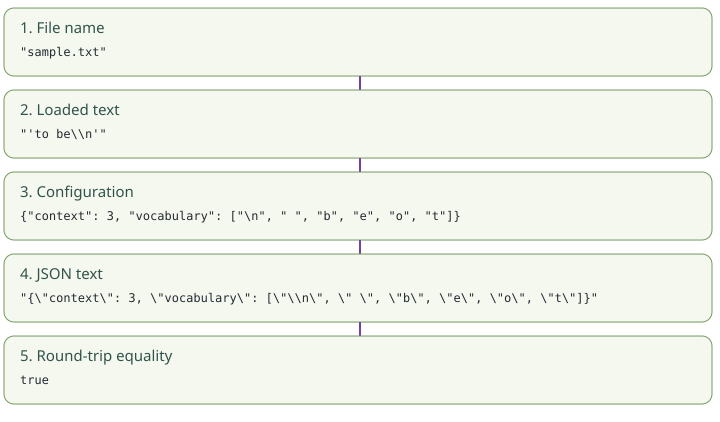

In [4]:
draw_trace()

### Read the implementation

From pathlib import Path brings one class into the current namespace. Importing json instead brings the module name, so its functions are reached through that name.

The with statement manages a resource lifetime. This example cleans up its temporary folder after the block, even when an exception occurs.

Read text with an explicit encoding. For a real dataset, validate the expected file rather than silently substituting unrelated text when loading fails.

Dumps converts a supported Python value into JSON text; loads parses JSON text back into a Python value. Their file-based relatives operate on open files.

A script's main guard separates work done when executed directly from definitions made available when imported. That keeps imports from unexpectedly starting training.

### Change one thing

**Read a UTF-8 accented word**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
from pathlib import Path
import json
import tempfile
with tempfile.TemporaryDirectory() as folder:
    path = Path(folder) / "sample.txt"
    path.write_text("to be\n" if not change else "café\n", encoding="utf-8")
    show("File name", path.name)
    text = path.read_text(encoding="utf-8")
    show("Loaded text", repr(text))
    config = {"context": 3, "vocabulary": sorted(set(text))}
    show("Configuration", config)
    serialized = json.dumps(config, ensure_ascii=False)
    show("JSON text", serialized)
    restored = json.loads(serialized)
    show("Round-trip equality", restored == config)

File name: "sample.txt"
Loaded text: "'café\\n'"
Configuration: {"context": 3, "vocabulary": ["\n", "a", "c", "f", "é"]}
JSON text: "{\"context\": 3, \"vocabulary\": [\"\\n\", \"a\", \"c\", \"f\", \"é\"]}"
Round-trip equality: true


### A useful distinction

A relative path depends on the working directory. JSON configuration does not contain model weights.

### ✋ Your turn

Serialize and restore {"context": 4, "heads": 2}, then put the restored dictionary in answer.

In [6]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == {"context": 4, "heads": 2}, 'A relative path depends on the working directory. JSON configuration does not contain model weights.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [7]:
#@title Show a solution { display-mode: "form" }
import json
answer = json.loads(json.dumps({"context": 4, "heads": 2}))

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == {"context": 4, "heads": 2}, 'A relative path depends on the working directory. JSON configuration does not contain model weights.'
    print("✓ right:", answer)

✓ right: {'context': 4, 'heads': 2}


### Reconnect to the transformer

The training recipe reads a dataset from a path and records configuration alongside its outputs. Those records allow a later notebook to interpret the run.

Import torch as a module and its functional namespace under an alias; these aliases are ordinary Python names, not special model syntax.

Weight files and configuration files serve different purposes. Tensor serialization will arrive in PyTorch, while JSON remains useful for human-readable settings.

The vocabulary's ordering must be preserved, not merely its number of entries. Otherwise loaded weights can be attached to different characters.

Next, group a vocabulary and the functions that use it into one object.

```python
text = Path(args.text).read_text(encoding="utf-8")
config_json = json.dumps(config, indent=2)
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What does json.loads receive?

<details><summary>Check your explanation</summary>

JSON text. A relative path depends on the working directory. JSON configuration does not contain model weights.

</details>